## This project applies Stochastic Gradient Descent (SGD) to predict the likelihood of a person being diagnosed with malaria based on classification of cell images in a Malaria Cell Images dataset. This involves implementing Logistic Regression and optimizing the parameters using SGD. The dataset contains 2 folders:
* Infected
* Uninfected

### And a total of 27,558 images.


In [1]:
#imports
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")

import kagglehub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

**Download, explore and preprocess the data**

In [2]:
#download the dataset
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\chalo\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1


In [3]:
#load the dataset
infected_path = os.path.join(path, "cell_images/Parasitized")
uninfected_path = os.path.join(path, "cell_images/Uninfected")
infected_images = os.listdir(infected_path)
uninfected_images = os.listdir(uninfected_path)
print("Number of infected images:", len(infected_images))
print("Number of uninfected images:", len(uninfected_images))

Number of infected images: 13780
Number of uninfected images: 13780


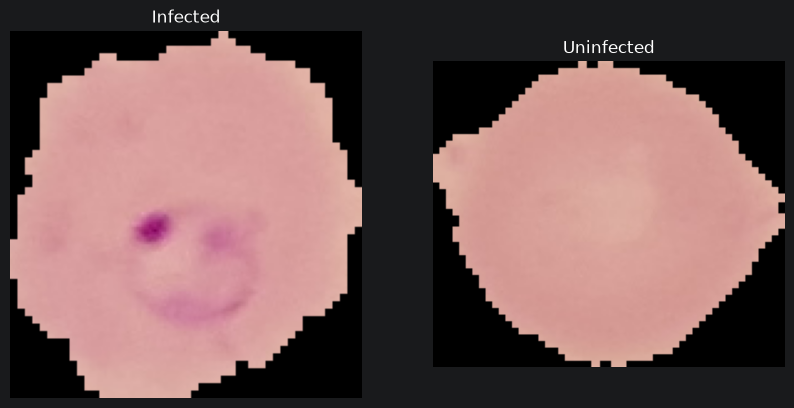

In [4]:
#explore the dataset and visualize an image from each folder
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(plt.imread(os.path.join(infected_path, infected_images[0])))
plt.title("Infected")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(plt.imread(os.path.join(uninfected_path, uninfected_images[0])))
plt.title("Uninfected")
plt.axis("off")
plt.show()

**preprocess the data and split into training, validation, and test sets**

In [5]:
# using fixed seed for reproducibility
SEED = 117

# reduce the image size to 32x32 pixels.
IMAGE_SIZE = (32, 32)

def load_images(folder, label):
    # convert every valid image in one class folder into one feature vector.
    features, labels = [], []
    for filename in sorted(os.listdir(folder)):
        file_path = os.path.join(folder, filename)
        # Grayscale is sufficient for this baseline and reduces each image to one channel.
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            # Skipping unreadable files prevents one corrupt image from stopping the pipeline.
            continue
        # INTER_AREA is a good choice when shrinking images because it averages pixels smoothly.
        image = cv2.resize(image, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
        # Logistic regression expects a tabular vector, so flatten 32x32 into 1,024 features therefore divide by 255 scales raw pixel values from [0, 255] to [0, 1].
        features.append(image.astype(np.float32).reshape(-1) / 255.0)
        labels.append(label)
    return np.asarray(features, dtype=np.float32), np.asarray(labels, dtype=np.int64)

# The target convention is explicit: Parasitized/malaria = 1 and Uninfected/not malaria = 0.
X_infected, y_infected = load_images(infected_path, 1)
X_uninfected, y_uninfected = load_images(uninfected_path, 0)
X = np.vstack([X_infected, X_uninfected])
y = np.concatenate([y_infected, y_uninfected])

In [6]:
# Stratification preserves the class ratio in every split, important for a reliable evaluation.
# First reserve 30%; splitting that portion in half gives 70% train, 15% validation, 15% test.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# Standardize with training-set statistics only. Using validation/test statistics would leak information.
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Constant pixels have zero variance; using 1 avoids division by zero for those features.
std[std < 1e-6] = 1.0
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print(f'Loaded {len(y):,} images with {X.shape[1]} features each.')
print(f'Train: {len(y_train):,} | Validation: {len(y_val):,} | Test: {len(y_test):,}')
print('Class counts (train):', dict(zip(*np.unique(y_train, return_counts=True))))

Loaded 27,558 images with 1024 features each.
Train: 19,290 | Validation: 4,134 | Test: 4,134
Class counts (train): {np.int64(0): np.int64(9645), np.int64(1): np.int64(9645)}


**train a binary logistic-regression model, evaluate it, and visualize its behavior**

In [7]:
# Sigmoid maps any real-valued score to a probability between 0 and 1.
def sigmoid(z):
    # Clipping prevents exp() from overflowing when scores become very large.
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

# log loss penalizes confident wrong predictions
def binary_cross_entropy(y_true, probabilities):
    # Clipping avoids log(0), which would produce undefined values.
    probabilities = np.clip(probabilities, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(probabilities) + (1 - y_true) * np.log(1 - probabilities))

# local generator makes the order of mini-batches reproducible without changing global randomness.
def train_logistic_sgd(X_train, y_train, X_val, y_val, learning_rate=0.003, epochs=40, batch_size=128, l2=1e-4, seed=42):
    local_rng = np.random.default_rng(seed)
    # Zero initialization is safe here because logistic regression has no hidden layers.
    weights = np.zeros(X_train.shape[1], dtype=np.float32)
    bias = 0.0
    # Keeping loss and accuracy after each epoch helps diagnose underfitting or overfitting.
    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        # Shuffle once per epoch so mini-batches do not always see examples in folder order.
        order = local_rng.permutation(len(y_train))
        for start in range(0, len(y_train), batch_size):
            batch = order[start:start + batch_size]
            # The linear score is converted to a malaria probability.
            probabilities = sigmoid(X_train[batch] @ weights + bias)
            # For logistic loss, predicted probability minus target is the gradient error.
            errors = probabilities - y_train[batch]
            # Batch size of 128 balances noisy updates with efficient matrix operations.
            # learning_rate=0.003 makes gradual updates; l2=1e-4 mildly discourages large weights.
            weights -= learning_rate * ((X_train[batch].T @ errors) / len(batch) + l2 * weights)
            # The bias has no input features, so its gradient is simply the mean error.
            bias -= learning_rate * errors.mean()

        # Evaluates after all mini-batches so each history point represents one complete epoch.
        train_prob = sigmoid(X_train @ weights + bias)
        val_prob = sigmoid(X_val @ weights + bias)
        history['train_loss'].append(binary_cross_entropy(y_train, train_prob))
        history['val_loss'].append(binary_cross_entropy(y_val, val_prob))
        history['train_accuracy'].append(accuracy_score(y_train, train_prob >= 0.5))
        history['val_accuracy'].append(accuracy_score(y_val, val_prob >= 0.5))

    return weights, bias, history

# epochs give repeated opportunities to improve while the validation curves reveal overfitting.
weights, bias, history = train_logistic_sgd(
    X_train, y_train, X_val, y_val,
    learning_rate=0.003, epochs=40, batch_size=128, l2=1e-4, seed=SEED
)

# Convert test probabilities to class predictions using 0.5, the natural threshold for balanced classes.
test_probabilities = sigmoid(X_test @ weights + bias)
y_pred = (test_probabilities >= 0.5).astype(int)

In [8]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1-score': f1_score(y_test, y_pred, zero_division=0)
}
print('Test-set performance:')
for name, value in metrics.items():
    print(f'{name}: {value:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not malaria (0)', 'Malaria (1)'], zero_division=0))

Test-set performance:
Accuracy: 0.6495
Precision: 0.6550
Recall: 0.6318
F1-score: 0.6432

                 precision    recall  f1-score   support

Not malaria (0)       0.64      0.67      0.66      2067
    Malaria (1)       0.65      0.63      0.64      2067

       accuracy                           0.65      4134
      macro avg       0.65      0.65      0.65      4134
   weighted avg       0.65      0.65      0.65      4134



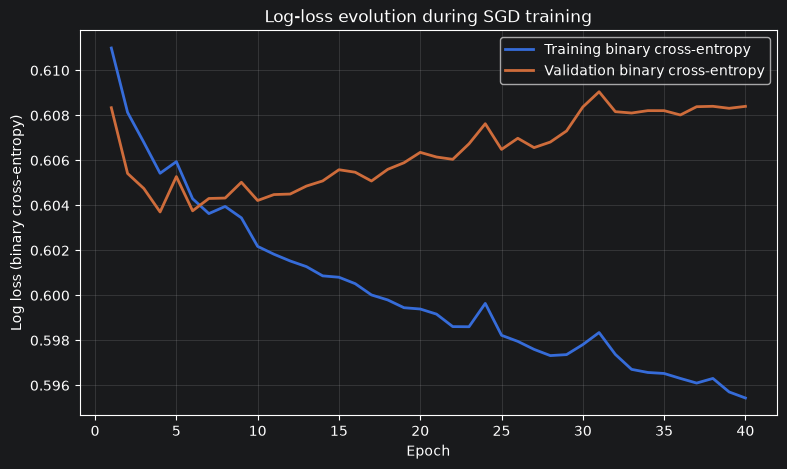

In [9]:
# Plotting binary cross-entropy to see whether SGD is reducing the optimization objective.
epochs_axis = np.arange(1, len(history['train_loss']) + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs_axis, history['train_loss'], label='Training binary cross-entropy', linewidth=2)
plt.plot(epochs_axis, history['val_loss'], label='Validation binary cross-entropy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Log loss (binary cross-entropy)')
plt.title('Log-loss evolution during SGD training')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

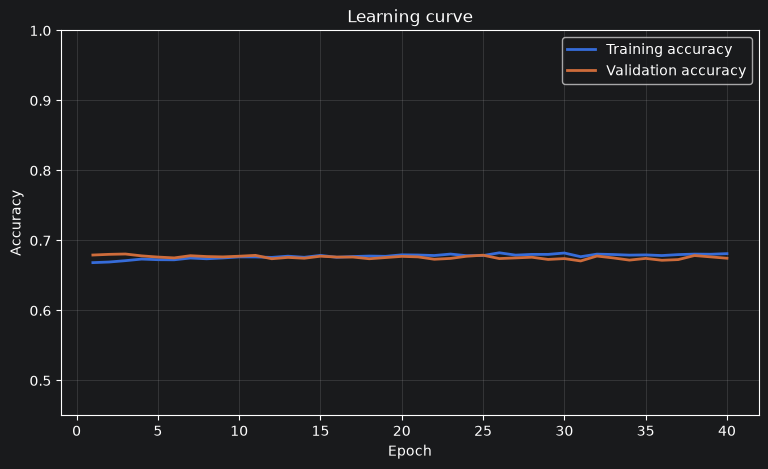

In [10]:
# learning curve compares training and validation accuracy as learning progresses.
plt.figure(figsize=(9, 5))
plt.plot(epochs_axis, history['train_accuracy'], label='Training accuracy', linewidth=2)
plt.plot(epochs_axis, history['val_accuracy'], label='Validation accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning curve')
plt.ylim(0.45, 1.0)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

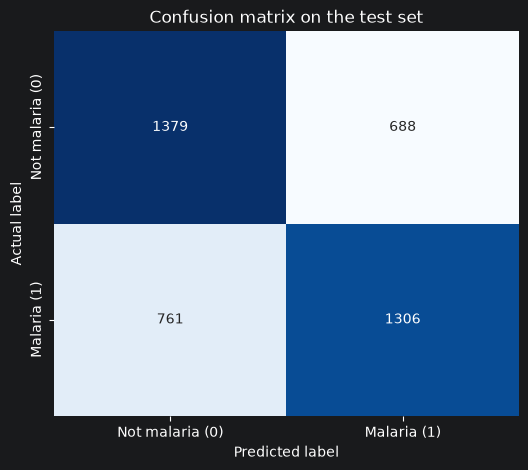

In [11]:
# The confusion matrix counts correct and incorrect predictions for both classes.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Not malaria (0)', 'Malaria (1)'],
    yticklabels=['Not malaria (0)', 'Malaria (1)']
)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('Confusion matrix on the test set')
plt.show()

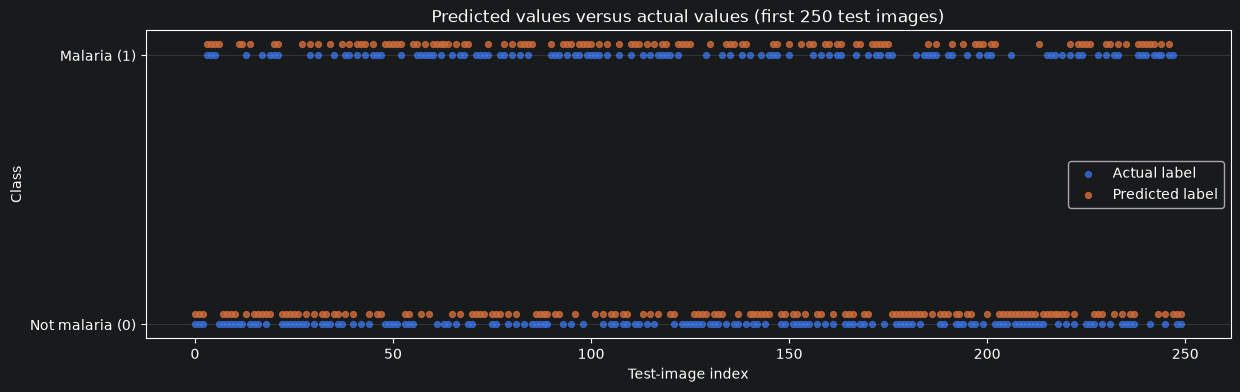

In [12]:
# Plotting a manageable, deterministic subset so actual and predicted class labels can be compared directly.
n_display = min(250, len(y_test))
display_idx = np.arange(n_display)
plt.figure(figsize=(14, 4))
plt.scatter(display_idx, y_test[:n_display], s=18, alpha=0.8, label='Actual label')
# The small +0.04 vertical offset makes overlapping predicted points visible.
plt.scatter(display_idx, y_pred[:n_display] + 0.04, s=18, alpha=0.8, label='Predicted label')
plt.yticks([0, 1], ['Not malaria (0)', 'Malaria (1)'])
plt.xlabel('Test-image index')
plt.ylabel('Class')
plt.title(f'Predicted values versus actual values (first {n_display} test images)')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.show()